# Pitch detection: autocorrelation vs HPS

In this notebook we implement and **compare two methods** for detecting the fundamental frequency ($F_0$, pitch) of a monophonic signal:

1. **Autocorrelation** - looks for periodicity in the time domain.
2. **HPS (Harmonic Product Spectrum)** - uses the harmonic structure in the frequency domain.

We compare them on synthetic tones (where we know the correct answer) and on a real recording, and then we discuss typical errors.

In [1]:
import sys
sys.path.append('../src')

import numpy as np
from matplotlib import pyplot as plt

import common as C
import pitch as P

## 1. From frequency to note

The reference note is $A_4 = 440$ Hz. Each semitone corresponds to multiplying the frequency by $2^{1/12}$, so the relationship between note and frequency is:

$$f = 440 \cdot 2^{(m-69)/12}, \qquad m = 69 + 12\log_2\!\frac{f}{440},$$

where $m$ is the note's MIDI number. We use this to convert measured frequencies into note names.

In [2]:
for m in [60, 69, 72]:
    f = C.note_to_freq(m)
    name, octave, _ = C.freq_to_note(f)
    print('MIDI %d -> %.2f Hz -> %s%d' % (m, f, name, octave))

MIDI 60 -> 261.63 Hz -> C4
MIDI 69 -> 440.00 Hz -> A4
MIDI 72 -> 523.25 Hz -> C5


## 2. Autocorrelation

Autocorrelation measures how similar the signal is to a time-shifted copy of itself:

$$r[\ell] = \sum_i x[i]\,x[i+\ell].$$

For a periodic signal, $r$ has pronounced peaks at multiples of the period. The first peak after zero gives the period $\ell_0$, and the frequency is $f_0 = F_s / \ell_0$.

We compute autocorrelation efficiently via the FFT (Wiener–Khinchin theorem),$r = \text{IFFT}(|\text{FFT}(x)|^2)$, giving complexity $O(n\log n)$ instead of $O(n^2)$.

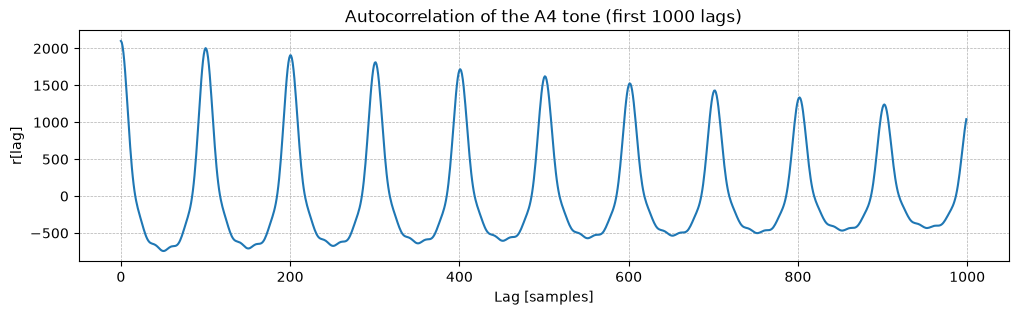

Detected: 440.00 Hz  (true: 440.00 Hz)


In [3]:
Fs = 44100
f0 = C.note_to_freq(69)   # A4 = 440 Hz
tone = C.generate_tone(f0, 0.05, Fs, num_harmonics=5, decay=0.7)

r = P.autocorrelation(tone)
plt.figure(figsize=(12, 3))
plt.plot(r[:1000])
plt.title('Autocorrelation of the A4 tone (first 1000 lags)')
plt.xlabel('Lag [samples]'); plt.ylabel('r[lag]')
plt.grid(linestyle='--', linewidth=0.5)
plt.show()

f_detected = P.detect_pitch_autocorrelation(tone, Fs, fmin=80, fmax=1200)
print('Detected: %.2f Hz  (true: %.2f Hz)' % (f_detected, f0))

The distance between peaks corresponds to the tone's period. With **parabolic interpolation** around the peak we get sub-sample accuracy.

## 3. HPS - Harmonic Product Spectrum

The harmonics of a real tone are integer multiples of the fundamental frequency. HPSexploits this: we multiply the spectrum by its "compressed" versions (every 2nd, 3rd, ... element). Wherever the harmonics line up at the fundamental frequency - the product gives the strongest peak.

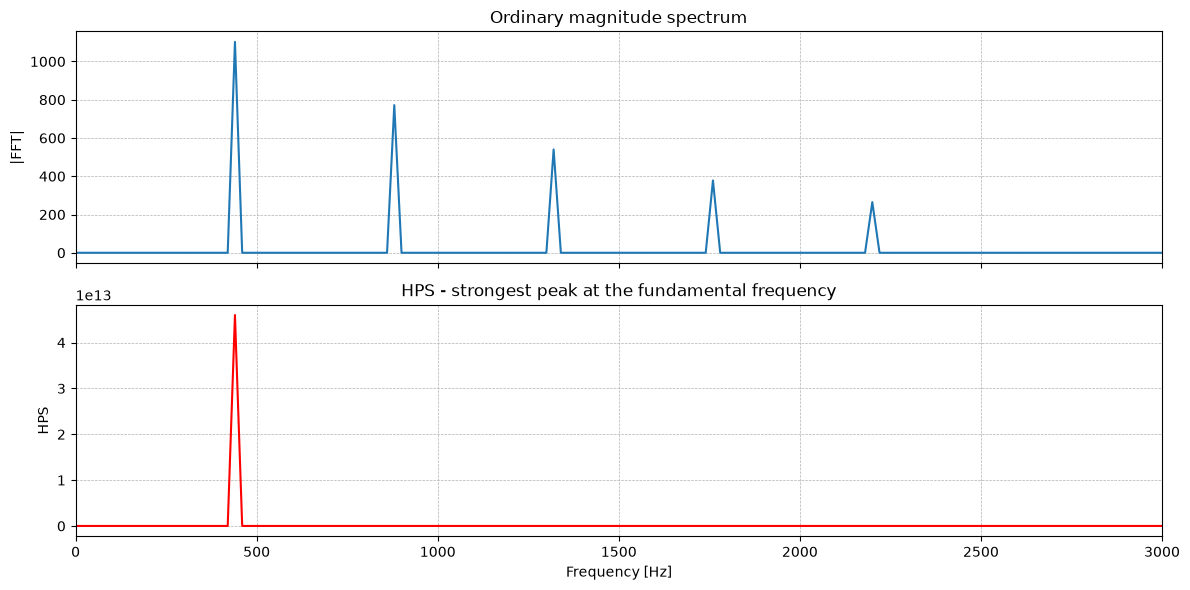

HPS detected: 440.00 Hz  (true: 440.00 Hz)


In [4]:
freqs, hps = P.harmonic_product_spectrum(tone, Fs, num_harmonics=5)
spectrum = np.abs(np.fft.rfft(tone))

fig, (a1, a2) = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
a1.plot(freqs, spectrum); a1.set_xlim(0, 3000)
a1.set_title('Ordinary magnitude spectrum'); a1.set_ylabel('|FFT|')
a1.grid(linestyle='--', linewidth=0.5)
a2.plot(freqs[:len(hps)], hps, color='red'); a2.set_xlim(0, 3000)
a2.set_title('HPS - strongest peak at the fundamental frequency')
a2.set_xlabel('Frequency [Hz]'); a2.set_ylabel('HPS')
a2.grid(linestyle='--', linewidth=0.5)
plt.tight_layout(); plt.show()

f_hps = P.detect_pitch_hps(tone, Fs, num_harmonics=5, fmin=80, fmax=1200)
print('HPS detected: %.2f Hz  (true: %.2f Hz)' % (f_hps, f0))

## 4. Comparing the methods on a range of tones

We test both methods on a scale of tones and compute the **MAE** (mean absolute error) and **RMSE** (root mean squared error).

In [5]:
np.random.seed(42)
midi_notes = list(range(48, 84)) # C3 .. B5
true_freqs = [C.note_to_freq(m) for m in midi_notes]

ac_measured, hps_measured = [], []
for f0 in true_freqs:
    x = C.generate_tone(f0, 0.2, Fs, num_harmonics=6, decay=0.7, noise_std=0.02)
    ac_measured.append(P.detect_pitch_autocorrelation(x, Fs, fmin=100, fmax=1200))
    hps_measured.append(P.detect_pitch_hps(x, Fs, num_harmonics=5, fmin=100, fmax=1200))

mae_ac, rmse_ac = P.errors(ac_measured, true_freqs)
mae_hps, rmse_hps = P.errors(hps_measured, true_freqs)
print('AUTOCORRELATION:   MAE = %.3f Hz    RMSE = %.3f Hz' % (mae_ac, rmse_ac))
print('HPS:               MAE = %.3f Hz    RMSE = %.3f Hz' % (mae_hps, rmse_hps))

AUTOCORRELATION:   MAE = 0.021 Hz    RMSE = 0.032 Hz
HPS:               MAE = 1.107 Hz    RMSE = 1.365 Hz


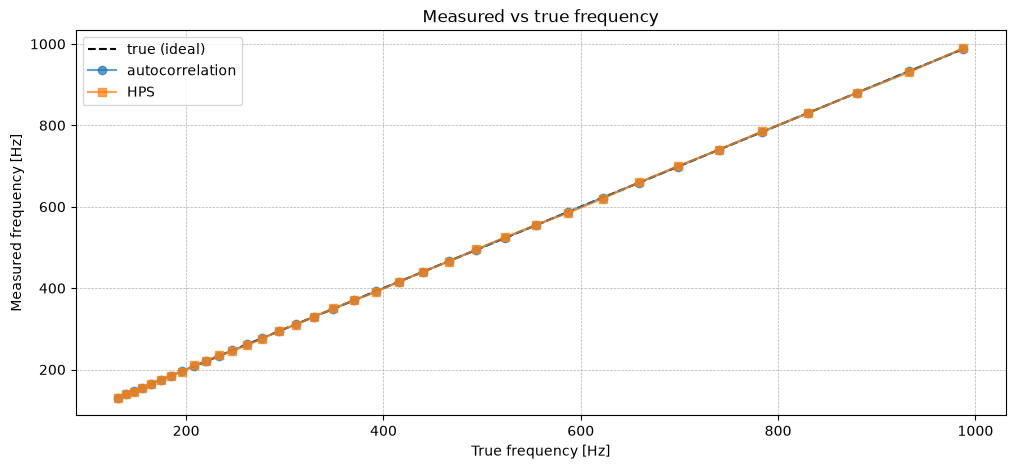

In [6]:
plt.figure(figsize=(12, 5))
plt.plot(true_freqs, true_freqs, 'k--', label='true (ideal)')
plt.plot(true_freqs, ac_measured, 'o-', label='autocorrelation', alpha=0.7)
plt.plot(true_freqs, hps_measured, 's-', label='HPS', alpha=0.7)
plt.xlabel('True frequency [Hz]')
plt.ylabel('Measured frequency [Hz]')
plt.title('Measured vs true frequency')
plt.legend(); plt.grid(linestyle='--', linewidth=0.5)
plt.show()

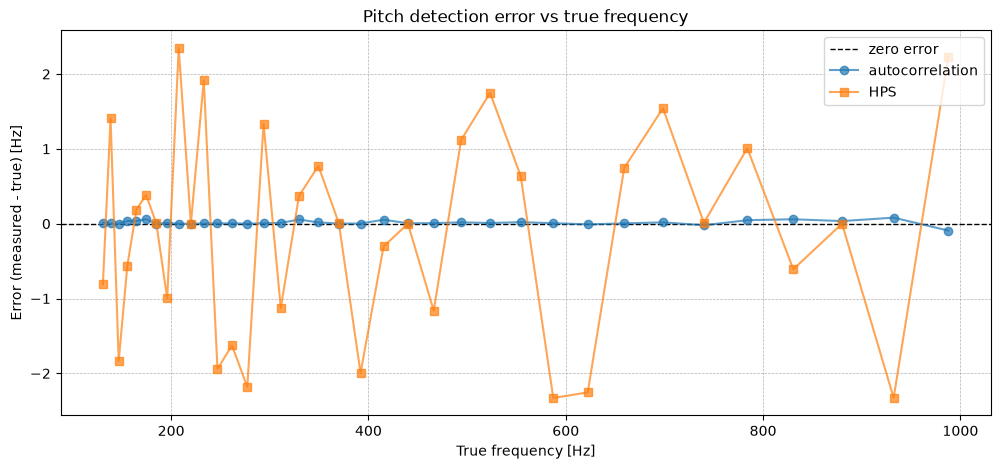

In [7]:
plt.figure(figsize=(12, 5))
plt.axhline(0, color='k', linestyle='--', linewidth=1, label='zero error')
plt.plot(true_freqs, np.array(ac_measured) - np.array(true_freqs), 'o-', label='autocorrelation', alpha=0.7)
plt.plot(true_freqs, np.array(hps_measured) - np.array(true_freqs), 's-', label='HPS', alpha=0.7)
plt.xlabel('True frequency [Hz]')
plt.ylabel('Error (measured - true) [Hz]')
plt.title('Pitch detection error vs true frequency')
plt.legend(); plt.grid(linestyle='--', linewidth=0.5)
plt.show()

**Observation.** Autocorrelation (with parabolic interpolation) is more precise since it isn't limited by the FFT bin resolution. HPS is coarser, but is known for its robustness to noise and for making octave errors less often.

## 5. Real recording and the limits of monophonic detection

Let's apply both methods to a segment of the `piano.wav` recording. Here the methods can diverge, which opens a discussion about **octave errors** and about how monophonic methods struggle with complex (polyphonic) sound.

In [8]:
import warnings
warnings.filterwarnings('ignore')

Fs, piano = C.load_wav('../data/piano.wav')

middle = len(piano)//2
segment = piano[middle:middle + int(0.3*Fs)]

f_ac = P.detect_pitch_autocorrelation(segment, Fs, fmin=80, fmax=1200)
f_hps = P.detect_pitch_hps(segment, Fs, num_harmonics=5, fmin=80, fmax=1200)
print('Autocorrelation: %.1f Hz -> %s%d' % (f_ac, *C.freq_to_note(f_ac)[:2]))
print('HPS:             %.1f Hz -> %s%d' % (f_hps, *C.freq_to_note(f_hps)[:2]))

Autocorrelation: 96.8 Hz -> G2
HPS:             220.0 Hz -> A3


The two methods disagree here: autocorrelation reports ~96.8 Hz (G2), HPS reports 220.0 Hz (A3) - a ratio of about $\times 2.27$, or roughly 14 semitones. That's close to a clean octave ($\times 2$, 12 semitones) but not exactly one, which is itself worth noting: on a synthetic tone, harmonics sit at exact integer multiples of $f_0$, so an
octave error there would show up as a clean $\times 2$ or $\times 0.5$. On a real piano, the overtones are slightly **inharmonic**, so a real octave-type error doesn't land on exactly $\times 2$.

This is still an **octave error**, just a real-world version of it: autocorrelation likely locked onto a lag about twice the true period, and HPS likely got pulled toward a strong harmonic instead of the true fundamental.


## Conclusion
- We implemented autocorrelation (with parabolic interpolation) and HPS.
- On synthetic tones, autocorrelation was more precise (lower MAE/RMSE).
- On the real recording, the methods can diverge - a good illustration of octave error.